In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
import zipfile

zip_path = "Downloads/PRCP-1001-RiceLeaf (1).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("rice_dataset")

In [17]:
dataset_path = "rice_dataset/Data"

classes = [
    "Bacterial leaf blight",
    "Brown spot",
    "Leaf smut"
]

print(classes)

['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [19]:
import os

for category in classes:
    
    path = os.path.join(dataset_path, category)
    
    print(category, ":", len(os.listdir(path)))

Bacterial leaf blight : 40
Brown spot : 40
Leaf smut : 39


In [23]:
data = []

for category in classes:
    folder = os.path.join(dataset_path, category)
    count = len(os.listdir(folder))
    data.append([category, count])

df = pd.DataFrame(data, columns=["Disease","Image Count"])
print(df)

                 Disease  Image Count
0  Bacterial leaf blight           40
1             Brown spot           40
2              Leaf smut           39


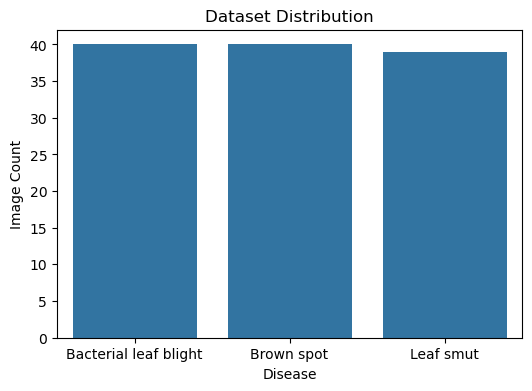

In [25]:
plt.figure(figsize=(6,4))
sns.barplot(x="Disease", y="Image Count", data=df)
plt.title("Dataset Distribution")
plt.show()

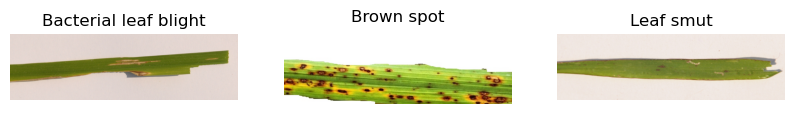

In [27]:
plt.figure(figsize=(10,6))

for i, category in enumerate(classes):
    
    folder = os.path.join(dataset_path, category)
    img_name = os.listdir(folder)[0]
    
    img_path = os.path.join(folder, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis("off")

plt.show()

In [29]:
IMG_SIZE = 128

X = []
y = []

for label, category in enumerate(classes):

    folder = os.path.join(dataset_path, category)

    for img_name in os.listdir(folder):

        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path)
        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))

        X.append(img)
        y.append(label)

X = np.array(X)
y = np.array(y)

print(X.shape)

(119, 128, 128, 3)


In [31]:
X = X / 255.0

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [35]:
datagen = ImageDataGenerator(

    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True

)

datagen.fit(X_train)

# Basic CNN

In [38]:
model1 = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(3,activation='softmax')

])

C:\Users\Shiva\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model1.compile(

    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

In [42]:
history1 = model1.fit(

    datagen.flow(X_train,y_train,batch_size=8),

    validation_data=(X_test,y_test),

    epochs=20

)

C:\Users\Shiva\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.3136 - loss: 1.3689 - val_accuracy: 0.3333 - val_loss: 1.0777
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.3553 - loss: 1.0958 - val_accuracy: 0.3750 - val_loss: 1.0068
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.3995 - loss: 1.0360 - val_accuracy: 0.5833 - val_loss: 0.9864
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.4745 - loss: 1.0232 - val_accuracy: 0.5417 - val_loss: 0.9699
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.4609 - loss: 0.9782 - val_accuracy: 0.6250 - val_loss: 0.8835
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.4805 - loss: 0.9135 - val_accuracy: 0.5417 - val_loss: 0.9282
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.6261 - loss: 0.8273 - val_accuracy: 0.7500 - val_loss: 0.6392
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.6506 - loss: 0.9158 - val_accuracy: 0.7

# Transfer Learning using MobileNetV2

In [45]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = MobileNetV2(

    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)

)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [47]:
model2 = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128,activation='relu'),

    Dropout(0.5),

    Dense(3,activation='softmax')

])

In [49]:
model2.compile(

    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

In [53]:
history2 = model2.fit(

    datagen.flow(X_train,y_train,batch_size=8),

    validation_data=(X_test,y_test),

    epochs=20

)

C:\Users\Shiva\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.9245 - loss: 0.1702 - val_accuracy: 0.8333 - val_loss: 0.4392
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.9468 - loss: 0.1301 - val_accuracy: 0.9167 - val_loss: 0.4166
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.9133 - loss: 0.1648 - val_accuracy: 0.8750 - val_loss: 0.2414
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.9638 - loss: 0.1283 - val_accuracy: 0.9167 - val_loss: 0.3420
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9502 - loss: 0.1711 - val_accuracy: 0.8333 - val_loss: 0.5009
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.9194 - loss: 0.1152 - val_accuracy: 0.8333 - val_loss: 0.4012
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.9513 - loss: 0.2046 - val_accuracy: 0.8750 - val_loss: 0.4100
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9912 - loss: 0.0468 - val_accuracy: 0.8750 - 

# Model Evaluation

In [65]:
pred = model2.predict(X_test)

y_pred = np.argmax(pred,axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step


In [66]:
print(classification_report(y_test,y_pred,target_names=classes))

                       precision    recall  f1-score   support

Bacterial leaf blight       0.78      1.00      0.88         7
           Brown spot       0.86      0.75      0.80         8
            Leaf smut       0.88      0.78      0.82         9

             accuracy                           0.83        24
            macro avg       0.84      0.84      0.83        24
         weighted avg       0.84      0.83      0.83        24



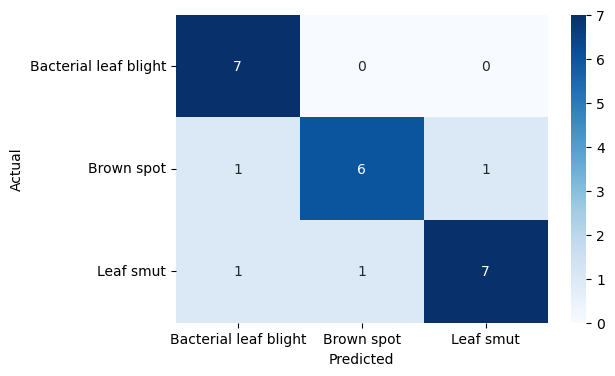

In [69]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Model Comparison

In [72]:
model1_acc = model1.evaluate(X_test,y_test)[1]
model2_acc = model2.evaluate(X_test,y_test)[1]

comparison = pd.DataFrame({

"Model":[
"Basic CNN",
"MobileNetV2 Transfer Learning"
],

"Accuracy":[
model1_acc,
model2_acc
]

})

print(comparison)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.7083 - loss: 0.8828
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.8333 - loss: 0.3018
                           Model  Accuracy
0                      Basic CNN  0.708333
1  MobileNetV2 Transfer Learning  0.833333


# Predicting on New Image

In [77]:
def predict_image(path):

    img = cv2.imread(path)
    img = cv2.resize(img,(128,128))
    img = img/255.0

    img = np.reshape(img,(1,128,128,3))

    pred = model2.predict(img)
    class_index = np.argmax(pred)

    print("Prediction:",classes[class_index])

In [83]:
predict_image("Downloads/images.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: Brown spot


In [85]:
predict_image('Downloads/riceleaf.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
Prediction: Leaf smut


# Challenges

**Challenge 1 — Small Dataset**

- Only 120 images, which can cause overfitting.

Solution:

- Data augmentation
- Transfer learning

**Challenge 2 — Class Similarity**

- Some diseases look visually similar.

Solution:

Deep CNN features

Pretrained networks

**Challenge 3 — Overfitting**

Solution:

- Dropout
- Augmentation
- Transfer learning

**Data Augmentation Report**

- increases dataset size
- improves generalization
- reduces overfitting

# Final Conclusion

Best model: **MobileNetV2**

Reasons:

- Highest accuracy
- Faster training
- Good feature extraction
- Suitable for production deployment.